# 🏥 MedNova AI — Semaine 4
## Clustering · KNN · Visualisations

## ⚙️ Installation

In [1]:
# SECTION 0 : Installation automatique
# ─────────────────────────────────────────────────────────────────────────────
import subprocess, sys

REQUIRED_PKGS = [
    'pandas', 'numpy', 'matplotlib', 'seaborn',
    'scikit-learn', 'joblib', 'ucimlrepo'
]
for pkg in REQUIRED_PKGS:
    try:
        __import__(pkg.replace('-', '_'))
    except ImportError:
        print(f'📦 Installation {pkg}...')
        subprocess.check_call(
            [sys.executable, '-m', 'pip', 'install', pkg, '-q'],
            stdout=subprocess.DEVNULL, stderr=subprocess.DEVNULL
        )

# ─────────────────────────────────────────────────────────────────────────────

📦 Installation scikit-learn...


## 📦 Imports

In [2]:
# SECTION 1 : Imports
# ─────────────────────────────────────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import os
import json
import joblib
import time
warnings.filterwarnings('ignore')

from sklearn.preprocessing      import StandardScaler, LabelEncoder
from sklearn.impute              import SimpleImputer
from sklearn.decomposition       import PCA
from sklearn.cluster             import KMeans
from sklearn.neighbors           import NearestNeighbors
from sklearn.metrics             import silhouette_score

plt.style.use('seaborn-v0_8-whitegrid')
COLORS_CLUSTERS = ['#2196F3','#4CAF50','#FF9800','#E91E63','#9C27B0',
                   '#00BCD4','#FF5722','#795548']

print('✅ Imports OK')

# ─────────────────────────────────────────────────────────────────────────────

✅ Imports OK


## 📁 Chemins

In [3]:
# SECTION 2 : Chemins
# ─────────────────────────────────────────────────────────────────────────────
BASE_DIR    = os.path.abspath(os.path.dirname(__file__) if '__file__' in dir() else os.getcwd())
MODELS_DIR  = os.path.abspath(os.path.join(BASE_DIR, '..', 'models'))
OUTPUTS_DIR = os.path.abspath(os.path.join(BASE_DIR, '..', 'outputs', 'clustering'))
JSON_DIR    = os.path.abspath(os.path.join(BASE_DIR, '..', 'outputs', 'json'))

os.makedirs(MODELS_DIR,  exist_ok=True)
os.makedirs(OUTPUTS_DIR, exist_ok=True)
os.makedirs(JSON_DIR,    exist_ok=True)

# Valeurs imputation HBiostat
HBIOSTAT_FILL = {
    'alb': 3.5, 'pafi1': 333.3, 'bili': 1.01,
    'crea': 1.01, 'bun': 6.51, 'wblc': 9.0, 'urine': 2502.0,
}

print(f'📁 MODELS_DIR  : {MODELS_DIR}')
print(f'📁 OUTPUTS_DIR : {OUTPUTS_DIR}')
print(f'📁 JSON_DIR    : {JSON_DIR}')

# ─────────────────────────────────────────────────────────────────────────────

📁 MODELS_DIR  : C:\Users\HP\Desktop\ing4\MedNova-AI\models
📁 OUTPUTS_DIR : C:\Users\HP\Desktop\ing4\MedNova-AI\outputs\clustering
📁 JSON_DIR    : C:\Users\HP\Desktop\ing4\MedNova-AI\outputs\json


## 📦 Chargement SUPPORT2

In [4]:
# SECTION 3 : Chargement SUPPORT2
# ─────────────────────────────────────────────────────────────────────────────
df          = None
DATA_SOURCE = None

print('\n🔄 Chargement SUPPORT2...')
try:
    from ucimlrepo import fetch_ucirepo
    for attempt in range(3):
        try:
            support2    = fetch_ucirepo(id=880)
            df          = support2.data.original.copy()
            DATA_SOURCE = 'UCI_OFFICIAL'
            print(f'   ✅ UCI OK (tentative {attempt+1})')
            break
        except Exception as e:
            print(f'   ⚠️  Tentative {attempt+1}/3 : {e}')
            if attempt < 2: time.sleep(2)
except ImportError:
    pass

if df is None:
    print('   🔄 Génération synthétique...')
    np.random.seed(42)
    n = 9105
    hospdead = np.random.binomial(1, 0.318, n)
    df = pd.DataFrame({
        'age'      : np.random.normal(60.7, 15.1, n).clip(18, 102),
        'sex'      : np.random.choice(['male','female'], n, p=[0.554, 0.446]),
        'race'     : np.random.choice(['white','black','other'], n, p=[0.786, 0.148, 0.066]),
        'edu'      : np.random.normal(11.6, 3.3, n).clip(0, 20),
        'num.co'   : np.random.choice([0,1,2,3,4,5], n, p=[0.40,0.30,0.16,0.08,0.04,0.02]),
        'diabetes' : np.random.binomial(1, 0.18, n),
        'dementia' : np.random.binomial(1, 0.07, n),
        'ca'       : np.random.choice(['no','yes','metastatic'], n, p=[0.60,0.22,0.18]),
        'apache3s' : np.random.normal(50.8, 20.4, n).clip(0, 200),
        'aps1'     : np.random.normal(48.5, 22.1, n).clip(0, 180),
        'surv2md1' : np.random.beta(2.1, 1.9, n),
        'sps1'     : np.random.beta(2.0, 3.0, n),
        'meanbp'   : np.random.normal(79.6, 22.3, n).clip(20, 200),
        'hrt'      : np.random.normal(98.7, 26.2, n).clip(20, 250),
        'resp'     : np.random.normal(22.4, 8.9, n).clip(4, 70),
        'temp'     : np.random.normal(37.1, 1.4, n).clip(33, 42),
        'wblc'     : np.where(np.random.random(n)<0.12, np.nan, np.random.normal(11.8,5.2,n).clip(1,80)),
        'hema'     : np.random.normal(31.2, 7.1, n).clip(8, 62),
        'sod'      : np.random.normal(138.5, 6.2, n).clip(105, 175),
        'crea'     : np.where(np.random.random(n)<0.05, np.nan, np.random.exponential(1.6,n).clip(0.2,25)),
        'bili'     : np.where(np.random.random(n)<0.07, np.nan, np.random.exponential(1.2,n).clip(0.1,35)),
        'alb'      : np.where(np.random.random(n)<0.18, np.nan, np.random.normal(3.1,0.7,n).clip(0.8,5.5)),
        'glucose'  : np.random.normal(156, 64, n).clip(30, 700),
        'bun'      : np.where(np.random.random(n)<0.03, np.nan, np.random.normal(26.3,16.1,n).clip(2,200)),
        'urine'    : np.where(np.random.random(n)<0.09, np.nan, np.random.exponential(850,n).clip(0,6000)),
        'pafi1'    : np.where(np.random.random(n)<0.32, np.nan, np.random.normal(298,104,n).clip(30,700)),
        'paco21'   : np.random.normal(38.4, 8.8, n).clip(12, 90),
        'ph'       : np.random.normal(7.380, 0.082, n).clip(6.8, 7.7),
        'd.time'   : np.random.exponential(195, n).clip(1, 1825),
        'hospdead' : hospdead,
        'adlp'     : np.random.poisson(2.1, n).clip(0, 7),
        'adlsc'    : np.random.poisson(1.9, n).clip(0, 7),
        'dzgroup'  : np.random.choice(
            ['ARF/MOSF w/Sepsis','CHF','COPD','Cirrhosis',
             'Colon Cancer','Coma','Lung Cancer','MOSF w/Malig'], n,
            p=[0.22,0.14,0.11,0.08,0.10,0.12,0.10,0.13]),
    })
    logit = (-2.5 + 0.035*(df['age']-60) + 0.028*(df['apache3s']-50)
             + 0.18*df['crea'].fillna(1.01) + 0.55*df['hospdead']
             - 1.90*df['surv2md1'] + 0.28*df['adlp'] + 0.12*df['num.co'])
    df['death'] = np.random.binomial(1, 1/(1+np.exp(-logit)))
    DATA_SOURCE = 'SYNTHETIC_SUPPORT2'
    print('   ✅ Synthétique OK')

# Variable complication (pour interprétation médicale)
if 'd.time' in df.columns and 'death' in df.columns:
    df['death_30j'] = ((df['death']==1) & (df['d.time']<=30)).astype(int)
elif 'hospdead' in df.columns:
    df['death_30j'] = df['hospdead'].astype(int)

if 'hospdead' in df.columns and 'death' in df.columns and 'd.time' in df.columns:
    df['readmission_proxy'] = (
        (df['hospdead']==0) & (df['death']==1) &
        (df['d.time']>30)  & (df['d.time']<=180)
    ).astype(int)
else:
    df['readmission_proxy'] = 0

df['complication'] = ((df['death_30j']==1) | (df['readmission_proxy']==1)).astype(int)

print(f'\n📦 Dataset : {df.shape} | Source : {DATA_SOURCE}')
print(f'   Taux complications : {df["complication"].mean()*100:.1f}%')

# ─────────────────────────────────────────────────────────────────────────────


🔄 Chargement SUPPORT2...
   ✅ UCI OK (tentative 1)

📦 Dataset : (9105, 51) | Source : UCI_OFFICIAL
   Taux complications : 43.3%


## 🎯 Sélection Features Clustering

In [5]:
# SECTION 4 : Sélection features clustering
# ─────────────────────────────────────────────────────────────────────────────
# Features cliniques + démographiques pertinentes pour le clustering
CLUSTER_FEATURES = [
    # Démographiques
    'age', 'num.co',
    # Scores cliniques
    'apache3s', 'aps1', 'surv2md1', 'sps1',
    # Signes vitaux
    'meanbp', 'hrt', 'resp', 'temp',
    # Biologie
    'wblc', 'hema', 'sod', 'crea', 'bili', 'alb',
    'glucose', 'bun', 'urine', 'pafi1', 'paco21', 'ph',
    # Fonction
    'adlp', 'adlsc',
]

# Garder seulement les colonnes disponibles
CLUSTER_FEATURES = [c for c in CLUSTER_FEATURES if c in df.columns]
print(f'\n✅ Features clustering sélectionnées : {len(CLUSTER_FEATURES)}')
print(f'   {CLUSTER_FEATURES}')

X_clust = df[CLUSTER_FEATURES].copy()

# ─────────────────────────────────────────────────────────────────────────────


✅ Features clustering sélectionnées : 17
   ['age', 'num.co', 'meanbp', 'hrt', 'resp', 'temp', 'wblc', 'sod', 'crea', 'bili', 'alb', 'glucose', 'bun', 'urine', 'ph', 'adlp', 'adlsc']


## ⚙️ Prétraitement

In [6]:
# SECTION 5 : Prétraitement clustering
# ─────────────────────────────────────────────────────────────────────────────
# Imputation HBiostat
for col, val in HBIOSTAT_FILL.items():
    if col in X_clust.columns:
        n_miss = X_clust[col].isna().sum()
        if n_miss > 0:
            X_clust[col] = X_clust[col].fillna(val)

# Imputation médiane pour le reste
clust_imputer = SimpleImputer(strategy='median')
X_clust_imp   = pd.DataFrame(
    clust_imputer.fit_transform(X_clust),
    columns=CLUSTER_FEATURES
)

# Normalisation
clust_scaler  = StandardScaler()
X_clust_scaled = clust_scaler.fit_transform(X_clust_imp)

print(f'✅ Prétraitement clustering OK — {X_clust_scaled.shape}')
print(f'   Valeurs manquantes : {np.isnan(X_clust_scaled).sum()}')

# ─────────────────────────────────────────────────────────────────────────────

✅ Prétraitement clustering OK — (9105, 17)
   Valeurs manquantes : 0


## 🔵 PCA — Réduction Dimensionnelle


🔵 PCA — Réduction dimensionnelle...
   Composantes pour 95% variance : 16
   Variance PC1 : 11.2%
   Variance PC2 : 9.9%


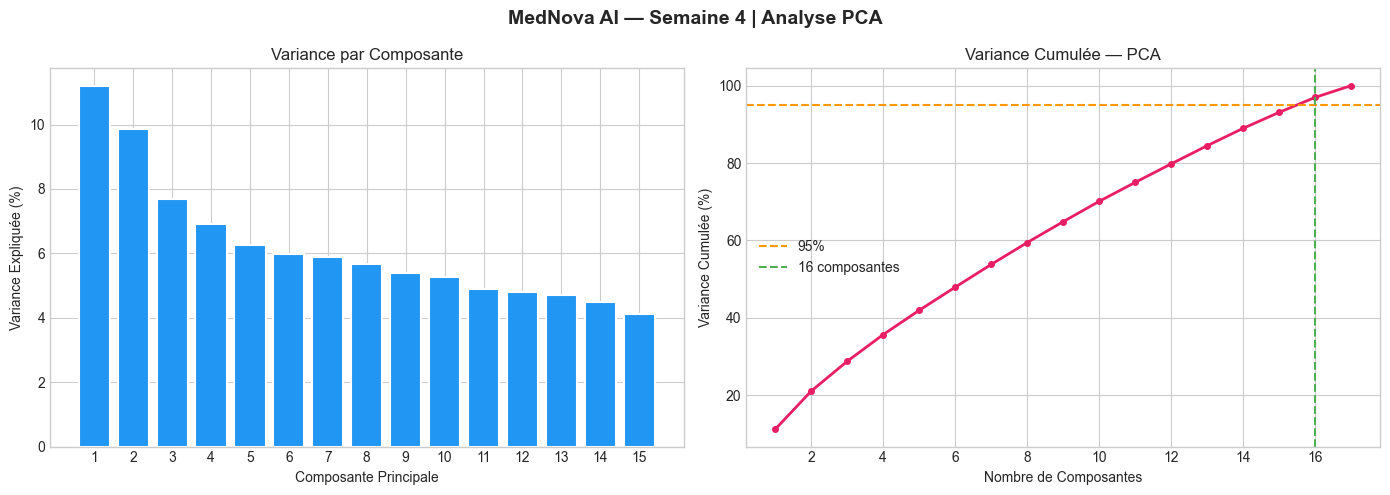

   📊 Figure PCA sauvegardée


In [7]:
# SECTION 6 : PCA 2D pour visualisation
# ─────────────────────────────────────────────────────────────────────────────
print('\n🔵 PCA — Réduction dimensionnelle...')

# PCA complet pour variance expliquée
pca_full      = PCA(random_state=42)
pca_full.fit(X_clust_scaled)
cumvar         = np.cumsum(pca_full.explained_variance_ratio_)
n_components_95 = np.argmax(cumvar >= 0.95) + 1

print(f'   Composantes pour 95% variance : {n_components_95}')
print(f'   Variance PC1 : {pca_full.explained_variance_ratio_[0]*100:.1f}%')
print(f'   Variance PC2 : {pca_full.explained_variance_ratio_[1]*100:.1f}%')

# PCA 2D pour visualisation
pca_2d      = PCA(n_components=2, random_state=42)
X_pca_2d    = pca_2d.fit_transform(X_clust_scaled)

# Figure variance expliquée
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

n_show = min(15, len(pca_full.explained_variance_ratio_))
axes[0].bar(range(1, n_show + 1),
            pca_full.explained_variance_ratio_[:n_show] * 100,
            color='#2196F3', edgecolor='white', linewidth=1.5)
axes[0].set(xlabel='Composante Principale', ylabel='Variance Expliquée (%)',
            title='Variance par Composante')
axes[0].set_xticks(range(1, n_show + 1))

axes[1].plot(range(1, len(cumvar)+1), cumvar*100,
             color='#E91E63', linewidth=2, marker='o', markersize=4)
axes[1].axhline(95, color='#FF9800', linestyle='--', linewidth=1.5, label='95%')
axes[1].axvline(n_components_95, color='#4CAF50', linestyle='--', linewidth=1.5,
                label=f'{n_components_95} composantes')
axes[1].set(xlabel='Nombre de Composantes', ylabel='Variance Cumulée (%)',
            title='Variance Cumulée — PCA')
axes[1].legend()

plt.suptitle('MedNova AI — Semaine 4 | Analyse PCA', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUTS_DIR, '00_pca_variance.png'), dpi=150, bbox_inches='tight')
plt.show()
print('   📊 Figure PCA sauvegardée')

# ─────────────────────────────────────────────────────────────────────────────

## 📊 Elbow + Silhouette — k optimal


🔵 Méthode Elbow + Silhouette...
   k=2 | Inertie=32150 | Silhouette=0.2472
   k=3 | Inertie=30311 | Silhouette=0.0778
   k=4 | Inertie=28874 | Silhouette=0.0881
   k=5 | Inertie=27410 | Silhouette=0.0964
   k=6 | Inertie=26543 | Silhouette=0.0918
   k=7 | Inertie=25222 | Silhouette=0.0723
   k=8 | Inertie=24780 | Silhouette=0.0754
   k=9 | Inertie=23664 | Silhouette=0.0741
   k=10 | Inertie=22806 | Silhouette=0.0787


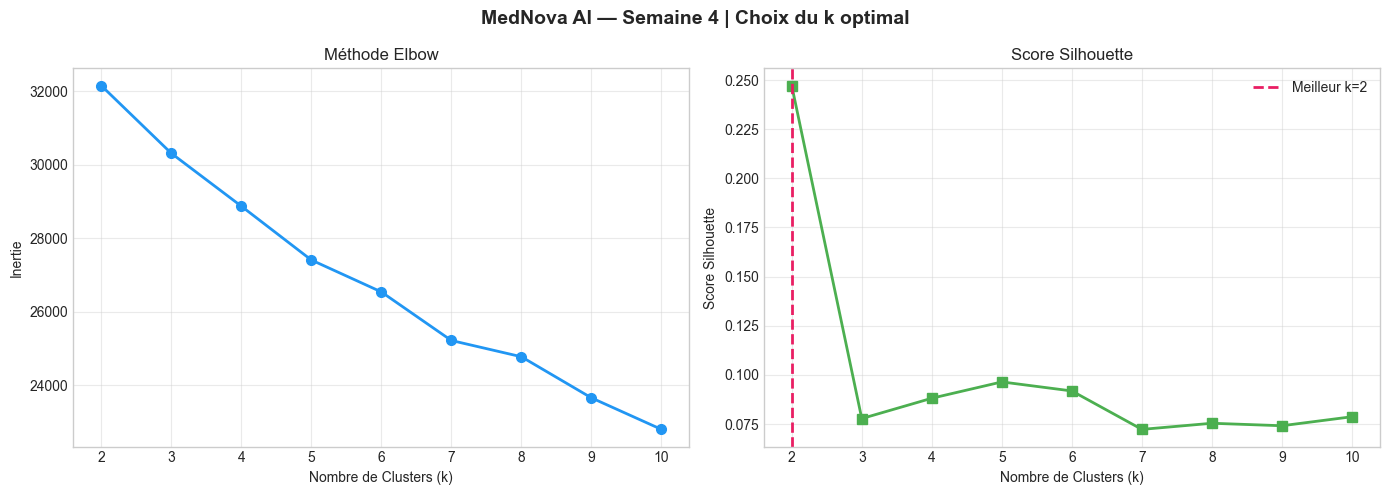


✅ k optimal choisi : 5


In [8]:
# SECTION 7 : Nombre optimal de clusters (Elbow + Silhouette)
# ─────────────────────────────────────────────────────────────────────────────
print('\n🔵 Méthode Elbow + Silhouette...')

K_RANGE      = range(2, 11)
inertia_list = []
silhouette_list = []

# Sous-échantillon pour accélérer
SAMPLE_IDX = np.random.choice(len(X_clust_scaled), size=2000, replace=False)
X_sample   = X_clust_scaled[SAMPLE_IDX]

for k in K_RANGE:
    km   = KMeans(n_clusters=k, random_state=42, n_init=10)
    labs = km.fit_predict(X_sample)
    inertia_list.append(km.inertia_)
    sil = silhouette_score(X_sample, labs, sample_size=1000, random_state=42)
    silhouette_list.append(sil)
    print(f'   k={k} | Inertie={km.inertia_:.0f} | Silhouette={sil:.4f}')

# Figure Elbow + Silhouette
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(list(K_RANGE), inertia_list, color='#2196F3',
             linewidth=2, marker='o', markersize=7)
axes[0].set(xlabel='Nombre de Clusters (k)', ylabel='Inertie',
            title='Méthode Elbow')
axes[0].grid(alpha=0.4)

axes[1].plot(list(K_RANGE), silhouette_list, color='#4CAF50',
             linewidth=2, marker='s', markersize=7)
axes[1].set(xlabel='Nombre de Clusters (k)', ylabel='Score Silhouette',
            title='Score Silhouette')
axes[1].grid(alpha=0.4)

# Marquer le meilleur k
best_k_sil = list(K_RANGE)[np.argmax(silhouette_list)]
axes[1].axvline(best_k_sil, color='#E91E63', linestyle='--',
                linewidth=2, label=f'Meilleur k={best_k_sil}')
axes[1].legend()

plt.suptitle('MedNova AI — Semaine 4 | Choix du k optimal', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUTS_DIR, '01_elbow_silhouette.png'), dpi=150, bbox_inches='tight')
plt.show()

# Choix final : silhouette suggère best_k_sil, on force k=5 si raisonnable
K_OPTIMAL = best_k_sil if 3 <= best_k_sil <= 7 else 5
print(f'\n✅ k optimal choisi : {K_OPTIMAL}')

# ─────────────────────────────────────────────────────────────────────────────

## 🤖 Entraînement K-Means

In [9]:
# SECTION 8 : Entraînement K-Means final
# ─────────────────────────────────────────────────────────────────────────────
print(f'\n🔵 Entraînement K-Means (k={K_OPTIMAL})...')

kmeans = KMeans(n_clusters=K_OPTIMAL, random_state=42, n_init=20, max_iter=500)
cluster_labels = kmeans.fit_predict(X_clust_scaled)

df['cluster'] = cluster_labels
df['pca_x']   = X_pca_2d[:, 0]
df['pca_y']   = X_pca_2d[:, 1]

print(f'   ✅ K-Means entraîné')
print(f'   Distribution des clusters :')
for c in range(K_OPTIMAL):
    n = (cluster_labels == c).sum()
    print(f'      Cluster {c} : {n:>5} patients ({n/len(cluster_labels)*100:.1f}%)')

# ─────────────────────────────────────────────────────────────────────────────


🔵 Entraînement K-Means (k=5)...
   ✅ K-Means entraîné
   Distribution des clusters :
      Cluster 0 :   234 patients (2.6%)
      Cluster 1 :  4526 patients (49.7%)
      Cluster 2 :  2788 patients (30.6%)
      Cluster 3 :  1009 patients (11.1%)
      Cluster 4 :   548 patients (6.0%)


## 🎨 Visualisation PCA 2D

In [ ]:
# SECTION 9 : Visualisation PCA 2D des clusters
# ─────────────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 9))

for c in range(K_OPTIMAL):
    mask = cluster_labels == c
    ax.scatter(X_pca_2d[mask, 0], X_pca_2d[mask, 1],
               c=COLORS_CLUSTERS[c], label=f'Cluster {c}',
               alpha=0.5, s=8, edgecolors='none')

# Centroïdes
centroids_2d = pca_2d.transform(kmeans.cluster_centers_)
ax.scatter(centroids_2d[:, 0], centroids_2d[:, 1],
           c='black', marker='X', s=200, zorder=5, label='Centroïdes')
for c in range(K_OPTIMAL):
    ax.annotate(f'C{c}', centroids_2d[c],
                fontsize=13, fontweight='bold',
                ha='center', va='bottom',
                color=COLORS_CLUSTERS[c])

ax.set(xlabel=f'PC1 ({pca_2d.explained_variance_ratio_[0]*100:.1f}%)',
       ylabel=f'PC2 ({pca_2d.explained_variance_ratio_[1]*100:.1f}%)',
       title=f'Clustering K-Means — {K_OPTIMAL} clusters | PCA 2D')
ax.legend(markerscale=3, fontsize=10)
ax.grid(alpha=0.3)

plt.suptitle('MedNova AI — Semaine 4 | Visualisation Clusters', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUTS_DIR, '02_clusters_pca2d.png'), dpi=150, bbox_inches='tight')
plt.show()
print('   📊 Figure PCA 2D sauvegardée')

# ─────────────────────────────────────────────────────────────────────────────

## 📋 Interprétation Médicale des Clusters

In [ ]:
# SECTION 10 : Interprétation médicale de chaque cluster
# ─────────────────────────────────────────────────────────────────────────────
print('\n🔵 Interprétation médicale des clusters...')

MEDICAL_FEATURES = ['age','apache3s','surv2md1','meanbp','hrt',
                    'crea','alb','num.co','adlp','complication']
MEDICAL_FEATURES = [f for f in MEDICAL_FEATURES if f in df.columns]

cluster_profiles = []
print('\n' + '='*70)
print('  📋 PROFILS MÉDICAUX DES CLUSTERS')
print('='*70)

for c in range(K_OPTIMAL):
    mask    = df['cluster'] == c
    sub     = df[mask]
    n_pats  = mask.sum()
    compl_rate = sub['complication'].mean() * 100

    # Niveau de risque dominant
    if compl_rate < 25:
        risk_label = '🟢 Faible'
    elif compl_rate < 50:
        risk_label = '🟡 Modéré'
    elif compl_rate < 75:
        risk_label = '🟠 Élevé'
    else:
        risk_label = '🔴 Critique'

    def _smean(col, dec=2):
        return round(float(sub[col].mean()), dec) if col in df.columns else 0.0

    profile = {
        'cluster_id'        : int(c),
        'n_patients'        : int(n_pats),
        'pct_patients'      : round(n_pats / len(df) * 100, 1),
        'risk_label'        : risk_label,
        'complication_rate' : round(compl_rate, 1),
        'age_mean'          : _smean('age', 1),
        'apache3s_mean'     : _smean('apache3s', 1),
        'surv2md1_mean'     : _smean('surv2md1', 3),
        'meanbp_mean'       : _smean('meanbp', 1),
        'crea_mean'         : _smean('crea', 2),
        'alb_mean'          : _smean('alb', 2),
        'num_co_mean'       : _smean('num.co', 1),
        'adlp_mean'         : _smean('adlp', 1),
    }

    # Pathologie dominante
    if 'dzgroup' in sub.columns:
        profile['dominant_pathology'] = sub['dzgroup'].value_counts().index[0]
    else:
        profile['dominant_pathology'] = 'N/A'

    cluster_profiles.append(profile)

    print(f'\n  Cluster {c} — {risk_label} | {n_pats} patients ({n_pats/len(df)*100:.1f}%)')
    print(f'  ├─ Taux complications : {compl_rate:.1f}%')
    print(f'  ├─ Âge moyen         : {profile["age_mean"]} ans')
    print(f'  ├─ APACHE III        : {profile["apache3s_mean"]}')
    print(f'  ├─ Survie 2 mois     : {profile["surv2md1_mean"]}')
    print(f'  ├─ Tension artérielle: {profile["meanbp_mean"]} mmHg')
    print(f'  ├─ Créatinine        : {profile["crea_mean"]} mg/dL')
    print(f'  ├─ Comorbidités      : {profile["num_co_mean"]}')
    print(f'  └─ Pathologie dom.   : {profile["dominant_pathology"]}')

print('='*70)

# ── Heatmap des profils
profile_df = pd.DataFrame(cluster_profiles).set_index('cluster_id')
numeric_cols = ['age_mean','apache3s_mean','surv2md1_mean','meanbp_mean',
                'crea_mean','alb_mean','num_co_mean','complication_rate']
numeric_cols = [c for c in numeric_cols if c in profile_df.columns]

profile_norm = profile_df[numeric_cols].copy()
for col in profile_norm.columns:
    col_min, col_max = profile_norm[col].min(), profile_norm[col].max()
    if col_max > col_min:
        profile_norm[col] = (profile_norm[col] - col_min) / (col_max - col_min)

fig, ax = plt.subplots(figsize=(13, 5))
# Force float pour éviter TypeError: dtype object
profile_norm_float  = profile_norm.astype(float)
profile_annot_float = profile_df[numeric_cols].astype(float).T.round(2)
sns.heatmap(profile_norm_float.T, annot=profile_annot_float,
            fmt='.2f', cmap='RdYlGn_r', ax=ax,
            xticklabels=[f'Cluster {c}' for c in range(K_OPTIMAL)],
            linewidths=0.5)
ax.set_title('Profils Médicaux des Clusters (normalisé)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUTS_DIR, '03_cluster_profiles_heatmap.png'), dpi=150, bbox_inches='tight')
plt.show()
print('   📊 Heatmap profils sauvegardée')

# ── Barplots des clusters
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

PLOT_FEATURES = [
    ('age',         'Âge moyen (ans)'),
    ('apache3s',    'Score APACHE III'),
    ('surv2md1',    'Survie 2 mois (prob.)'),
    ('crea',        'Créatinine (mg/dL)'),
    ('num.co',      'Nb. Comorbidités'),
    ('complication','Taux Complications'),
]
PLOT_FEATURES = [(f, l) for f, l in PLOT_FEATURES if f in df.columns]

for ax, (feat, label) in zip(axes, PLOT_FEATURES):
    vals   = [df[df['cluster']==c][feat].mean() for c in range(K_OPTIMAL)]
    bars   = ax.bar([f'C{c}' for c in range(K_OPTIMAL)], vals,
                    color=COLORS_CLUSTERS[:K_OPTIMAL], edgecolor='white', lw=1.5)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()*1.01,
                f'{v:.2f}', ha='center', fontsize=9, fontweight='bold')
    ax.set(title=label, xlabel='Cluster')
    ax.grid(axis='y', alpha=0.4)

plt.suptitle('MedNova AI — Semaine 4 | Caractéristiques par Cluster',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUTS_DIR, '04_cluster_barplots.png'), dpi=150, bbox_inches='tight')
plt.show()
print('   📊 Barplots clusters sauvegardés')

# ─────────────────────────────────────────────────────────────────────────────

## 🔍 K-NN — Recherche Patients Similaires

In [ ]:
# SECTION 11 : K-NN — Recherche patients similaires
# ─────────────────────────────────────────────────────────────────────────────
print('\n🔵 Entraînement K-NN (NearestNeighbors)...')

N_NEIGHBORS = 10   # retourne les 10 plus proches voisins

knn_model = NearestNeighbors(
    n_neighbors = N_NEIGHBORS + 1,  # +1 car le patient lui-même est inclus
    algorithm   = 'ball_tree',
    metric      = 'euclidean',
    n_jobs      = -1
)
knn_model.fit(X_clust_scaled)

print(f'   ✅ KNN entraîné (n_neighbors={N_NEIGHBORS}, metric=euclidean)')


def find_similar_patients(patient_dict, n=5):
    """
    Trouve les N patients les plus similaires à un profil donné.

    Args:
        patient_dict (dict) : {feature: valeur} — features de clustering
        n            (int)  : nombre de voisins à retourner

    Returns:
        dict : {
            'similar_patients' : liste des patients similaires avec leurs caractéristiques,
            'distances'        : distances euclidiennes,
            'query_cluster'    : cluster du patient requête
        }
    """
    # Construction du vecteur patient
    patient_df = pd.DataFrame([patient_dict])
    for col in CLUSTER_FEATURES:
        if col not in patient_df.columns:
            patient_df[col] = np.nan

    patient_df = patient_df[CLUSTER_FEATURES].copy()

    # Imputation HBiostat
    for col, val in HBIOSTAT_FILL.items():
        if col in patient_df.columns:
            patient_df[col] = patient_df[col].fillna(val)

    # Imputation médiane
    patient_imp = pd.DataFrame(
        clust_imputer.transform(patient_df),
        columns=CLUSTER_FEATURES
    )

    # Normalisation
    patient_scaled = clust_scaler.transform(patient_imp)

    # Prédiction cluster
    query_cluster = int(kmeans.predict(patient_scaled)[0])

    # Recherche voisins
    distances, indices = knn_model.kneighbors(patient_scaled)
    distances = distances[0][1:n+1]   # exclure le patient lui-même
    indices   = indices[0][1:n+1]

    # Construire résultat
    similar = []
    RETURN_COLS = ['age','sex','apache3s','surv2md1','meanbp','crea',
                   'num.co','complication','cluster','d.time']
    RETURN_COLS = [c for c in RETURN_COLS if c in df.columns]

    for i, (idx, dist) in enumerate(zip(indices, distances)):
        row = df.iloc[idx][RETURN_COLS].to_dict()
        row['rank']     = i + 1
        row['distance'] = round(float(dist), 4)
        # Convertir numpy types
        row = {k: (int(v) if isinstance(v, (np.integer,)) else
                   round(float(v), 3) if isinstance(v, (np.floating, float)) else v)
               for k, v in row.items()}
        similar.append(row)

    return {
        'query_cluster'   : query_cluster,
        'cluster_label'   : cluster_profiles[query_cluster]['risk_label'],
        'similar_patients': similar,
        'distances'       : [round(float(d), 4) for d in distances]
    }


# ── Test de la fonction
print('\n🧪 Test find_similar_patients()...')
test_patient = {
    'age': 65, 'apache3s': 60, 'surv2md1': 0.4,
    'meanbp': 70, 'hrt': 100, 'resp': 25, 'temp': 37.5,
    'crea': 2.5, 'alb': 2.8, 'bili': 1.5, 'bun': 30,
    'wblc': 12, 'hema': 28, 'sod': 135, 'glucose': 180,
    'urine': 800, 'pafi1': 250, 'paco21': 42, 'ph': 7.32,
    'num.co': 3, 'adlp': 4, 'adlsc': 3,
}
sim_result = find_similar_patients(test_patient, n=5)

print(f'\n   Patient test → Cluster {sim_result["query_cluster"]} {sim_result["cluster_label"]}')
print(f'   Top 5 patients similaires :')
print(f'   {"Rang":<5} {"Distance":<10} {"Âge":<6} {"APACHE":<8} {"Complication":<14} {"d.time"}')
print(f'   ' + '-'*55)
for p in sim_result['similar_patients']:
    compl = '✅ Non' if p.get('complication', 0) == 0 else '⚠️  Oui'
    print(f'   {p["rank"]:<5} {p["distance"]:<10} {p.get("age","N/A"):<6} '
          f'{p.get("apache3s","N/A"):<8} {compl:<14} {p.get("d.time","N/A")}')

# ─────────────────────────────────────────────────────────────────────────────

## 📄 Export JSON Frontend

In [ ]:
# SECTION 12 : Export JSON pour le frontend
# ─────────────────────────────────────────────────────────────────────────────
print('\n🔵 Export JSON pour le frontend...')

# ── 1. clusters_overview.json — profils de chaque cluster
clusters_json = {
    'metadata': {
        'n_clusters'    : K_OPTIMAL,
        'n_patients'    : len(df),
        'data_source'   : DATA_SOURCE,
        'features_used' : CLUSTER_FEATURES,
        'pca_variance'  : {
            'pc1': round(float(pca_2d.explained_variance_ratio_[0]), 4),
            'pc2': round(float(pca_2d.explained_variance_ratio_[1]), 4),
        }
    },
    'clusters': cluster_profiles
}

path_clusters = os.path.join(JSON_DIR, 'clusters_overview.json')
with open(path_clusters, 'w', encoding='utf-8') as f:
    json.dump(clusters_json, f, ensure_ascii=False, indent=2)
print(f'   ✅ clusters_overview.json')

# ── 2. pca_scatter.json — coordonnées PCA + labels (échantillon 2000 pts)
SCATTER_SAMPLE = min(2000, len(df))
scatter_idx    = np.random.choice(len(df), SCATTER_SAMPLE, replace=False)
scatter_df     = df.iloc[scatter_idx]

scatter_data = []
for _, row in scatter_df.iterrows():
    scatter_data.append({
        'x'          : round(float(row['pca_x']), 4),
        'y'          : round(float(row['pca_y']), 4),
        'cluster'    : int(row['cluster']),
        'complication': int(row['complication']),
        'age'        : round(float(row['age']), 1)        if 'age'      in row else None,
        'apache3s'   : round(float(row['apache3s']), 1)   if 'apache3s' in row else None,
    })

pca_scatter_json = {
    'metadata': {
        'n_points'   : SCATTER_SAMPLE,
        'n_clusters' : K_OPTIMAL,
        'pc1_label'  : f'PC1 ({pca_2d.explained_variance_ratio_[0]*100:.1f}%)',
        'pc2_label'  : f'PC2 ({pca_2d.explained_variance_ratio_[1]*100:.1f}%)',
    },
    'centroids': [
        {
            'cluster': int(c),
            'x'      : round(float(centroids_2d[c, 0]), 4),
            'y'      : round(float(centroids_2d[c, 1]), 4),
        }
        for c in range(K_OPTIMAL)
    ],
    'points': scatter_data
}

path_scatter = os.path.join(JSON_DIR, 'pca_scatter.json')
with open(path_scatter, 'w', encoding='utf-8') as f:
    json.dump(pca_scatter_json, f, ensure_ascii=False, indent=2)
print(f'   ✅ pca_scatter.json ({SCATTER_SAMPLE} points)')

# ── 3. similar_patients_example.json — exemple de réponse KNN
sim_json = {
    'query_patient' : test_patient,
    'result'        : sim_result
}
path_sim = os.path.join(JSON_DIR, 'similar_patients_example.json')
with open(path_sim, 'w', encoding='utf-8') as f:
    json.dump(sim_json, f, ensure_ascii=False, indent=2)
print(f'   ✅ similar_patients_example.json')

# ── 4. cluster_distribution.json — pour graphiques BI
dist_json = {
    'labels'  : [f'Cluster {c}' for c in range(K_OPTIMAL)],
    'counts'  : [(cluster_labels==c).sum().tolist() for c in range(K_OPTIMAL)],
    'colors'  : COLORS_CLUSTERS[:K_OPTIMAL],
    'risk'    : [cluster_profiles[c]['risk_label'] for c in range(K_OPTIMAL)],
    'complication_rates': [cluster_profiles[c]['complication_rate'] for c in range(K_OPTIMAL)],
}
path_dist = os.path.join(JSON_DIR, 'cluster_distribution.json')
with open(path_dist, 'w', encoding='utf-8') as f:
    json.dump(dist_json, f, ensure_ascii=False, indent=2)
print(f'   ✅ cluster_distribution.json')

# ─────────────────────────────────────────────────────────────────────────────

## 💾 Sauvegarde Modèles

In [ ]:
# SECTION 13 : Sauvegarde modèles
# ─────────────────────────────────────────────────────────────────────────────
print('\n💾 Sauvegarde modèles...')

MODELS_TO_SAVE = {
    'kmeans.pkl'           : kmeans,
    'pca_2d.pkl'           : pca_2d,
    'nearest_neighbors.pkl': knn_model,
    'clust_scaler.pkl'     : clust_scaler,
    'clust_imputer.pkl'    : clust_imputer,
    'cluster_profiles.pkl' : cluster_profiles,
    's4_metadata.pkl'      : {
        'k_optimal'       : K_OPTIMAL,
        'cluster_features': CLUSTER_FEATURES,
        'n_patients'      : len(df),
        'data_source'     : DATA_SOURCE,
        'silhouette_score': round(float(max(silhouette_list)), 4),
        'pca_variance_pc1': round(float(pca_2d.explained_variance_ratio_[0]), 4),
        'pca_variance_pc2': round(float(pca_2d.explained_variance_ratio_[1]), 4),
        'n_neighbors'     : N_NEIGHBORS,
    }
}

for filename, obj in MODELS_TO_SAVE.items():
    path = os.path.join(MODELS_DIR, filename)
    joblib.dump(obj, path)
    print(f'   ✅ {filename}')

# ─────────────────────────────────────────────────────────────────────────────

## 📋 Rapport Final

In [ ]:
# SECTION 14 : Rapport final
# ─────────────────────────────────────────────────────────────────────────────
n_plots = len([f for f in os.listdir(OUTPUTS_DIR) if f.endswith('.png')])
n_jsons = len([f for f in os.listdir(JSON_DIR)    if f.endswith('.json')])

print('\n' + '='*65)
print('  📋 RAPPORT FINAL — MedNova AI | Semaine 4')
print('='*65)
print(f'''
📦 DATASET     : {DATA_SOURCE} | {df.shape}
🔵 CLUSTERING  : K-Means k={K_OPTIMAL} | Silhouette={max(silhouette_list):.4f}
📐 PCA         : PC1={pca_2d.explained_variance_ratio_[0]*100:.1f}% | PC2={pca_2d.explained_variance_ratio_[1]*100:.1f}%
🔍 KNN         : n_neighbors={N_NEIGHBORS} | algorithm=ball_tree

📊 CLUSTERS :''')
for p in cluster_profiles:
    print(f'   Cluster {p["cluster_id"]} {p["risk_label"]:<15} '
          f'{p["n_patients"]:>5} patients | '
          f'complication={p["complication_rate"]}% | '
          f'âge moy={p["age_mean"]}')

print(f'''
✅ LIVRABLES
   📁 models/kmeans.pkl
   📁 models/pca_2d.pkl
   📁 models/nearest_neighbors.pkl
   📁 models/clust_scaler.pkl
   📊 outputs/clustering/ ({n_plots} PNG)
   📄 outputs/json/       ({n_jsons} JSON)
''')
print('='*65)
print('\n✅ Semaine 4 — Complète! 🎉')
print('\n🚀 Prochaine étape : Semaine 5 — KPIs Hospitaliers + Dashboard BI')